**Proyecto Integrador 3: Analisis de Sentimientos**

**Declaración del problema**: Nuestra agencia fue contratada por un grupo restaurantero con el fin de implementar un modelo de análisis de sentimientos, facilitando así la comprensión de la opinión de sus clientes en entornos digitales.

In [1]:
# Importando las librerías

# Para leer y manipular los datos
import pandas as pd
pd.set_option('max_colwidth', None)

# Para las gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Apoya en mostrar las imágenes
from PIL import Image

# Ayuda a extraer los datos utilizando expresiones regulares.
import re

# Apoya en remover la puntuación
import string

#Instala Unidecode
! pip install Unidecode


# Apoya en remover los acentos
import unidecode

# Importa la librería NLTK (Natural Language Toolkit)
import nltk

nltk.download('stopwords')    # Carga las stopwords
nltk.download('punkt')        # Para la tokenización
nltk.download('omw-1.4')      # Carga una dependencia necesaria para la tokenización
nltk.download('wordnet')      # Cargando el módulo WordNet, utilizado en el stemming y la lematización.

# Baja el léxico de VADED
nltk.download('vader_lexicon')

from nltk.corpus import stopwords

# Apoyo en la creación de Word clouds
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Usaddo en la lematización
from nltk.stem.porter import PorterStemmer


# Usaddo en la lematización
from nltk.stem import WordNetLemmatizer


from sklearn.feature_extraction.text import CountVectorizer          #Para BofW
from sklearn.feature_extraction.text import TfidfVectorizer          #ParaTF-IDF

# Creación de train y test
from sklearn.model_selection import train_test_split

# Para crear el modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier

# Para generar las métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# MODELOS NO SUPERVISADOS

# Instalando VADER
!pip install vaderSentiment

# Instalando TextBlob
!pip install textblob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## **Cargando la base de datos**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Restaurant_Reviews.csv to Restaurant_Reviews (2).csv


In [3]:
# Creando un dataframe para la base obtenida
reviews = pd.read_csv("Restaurant_Reviews.csv")

In [4]:
# Creando una copia
data = reviews.copy()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Review    9950 non-null   object 
 1   Rating    9950 non-null   float64
 2   Metadata  9950 non-null   object 
 3   Time      9950 non-null   object 
 4   Pictures  9950 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 388.8+ KB


In [6]:
data.head()

,Review,Rating,Metadata,Time,Pictures
0,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was really courteous and helpful.",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",5.0,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [7]:
# Revisando valores duplicados
data.duplicated().sum()

np.int64(0)

Haremos drop a las variables que no aportan información al modelo

In [8]:
data.drop(columns=['Metadata',"Time","Pictures"], inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Review  9950 non-null   object 
 1   Rating  9950 non-null   float64
dtypes: float64(1), object(1)
memory usage: 155.6+ KB


# **Análisis de datos exploratorio**

El cliente nos indico que, los comentarios con rating mayor que 3 es positivo, menor que 3 sera negativo.

In [10]:
# Viendo el % de las etiquetas
data['Rating'].value_counts(True)

,proportion
Rating,
5.0,0.384422
4.0,0.238392
1.0,0.174271
3.0,0.119698
2.0,0.068744
4.5,0.006935
3.5,0.004724
2.5,0.001910
1.5,0.000905


In [11]:
import numpy as np

data['Sentiment'] = np.where(data['Rating'] >= 3, 'positivo', 'negativo')

In [12]:
# Viendo el % de las etiquetas
data['Sentiment'].value_counts(True)

,proportion
Sentiment,
positivo,0.754171
negativo,0.245829


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9950 entries, 0 to 9949
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Review     9950 non-null   object 
 1   Rating     9950 non-null   float64
 2   Sentiment  9950 non-null   object 
dtypes: float64(1), object(2)
memory usage: 233.3+ KB


In [14]:
data.drop(columns=['Rating'], inplace=True)

In [15]:
# Creando una wordcloud para los valores negativos

negative_reviews = data[data['Sentiment'] == "negativo"]

words = ' '.join(negative_reviews['Review'])

cleaned_word = " ".join([word for word in words.split()])

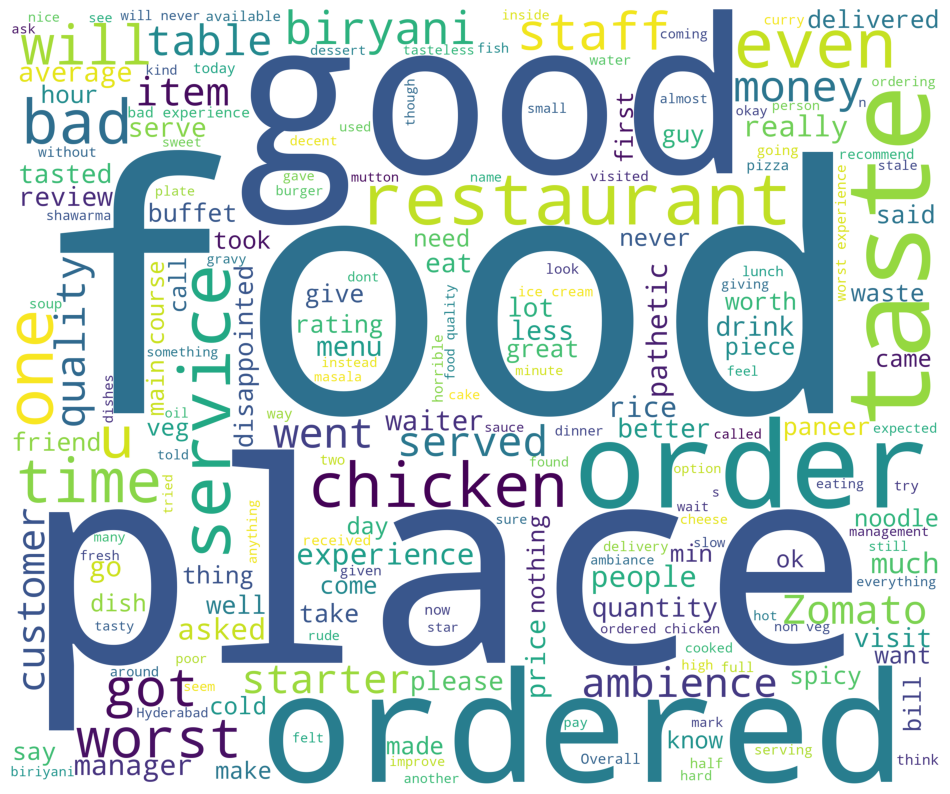

In [16]:
wordcloud = WordCloud(stopwords = STOPWORDS,
                      background_color = 'white',
                      width = 3000,
                      height = 2500
                     ).generate(cleaned_word)


plt.figure(1, figsize = (12, 12))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

Podemos ver que, las palabras Place, good, food, taste y ordered, fueron las mas mencionadas en los comentarios negativos.

In [17]:
# Creando el word cloud para los sentimientos positivos
positive_reviews = data[data['Sentiment'] == "positivo"]

words = ' '.join(positive_reviews['Review'])

cleaned_word = " ".join([word for word in words.split()])

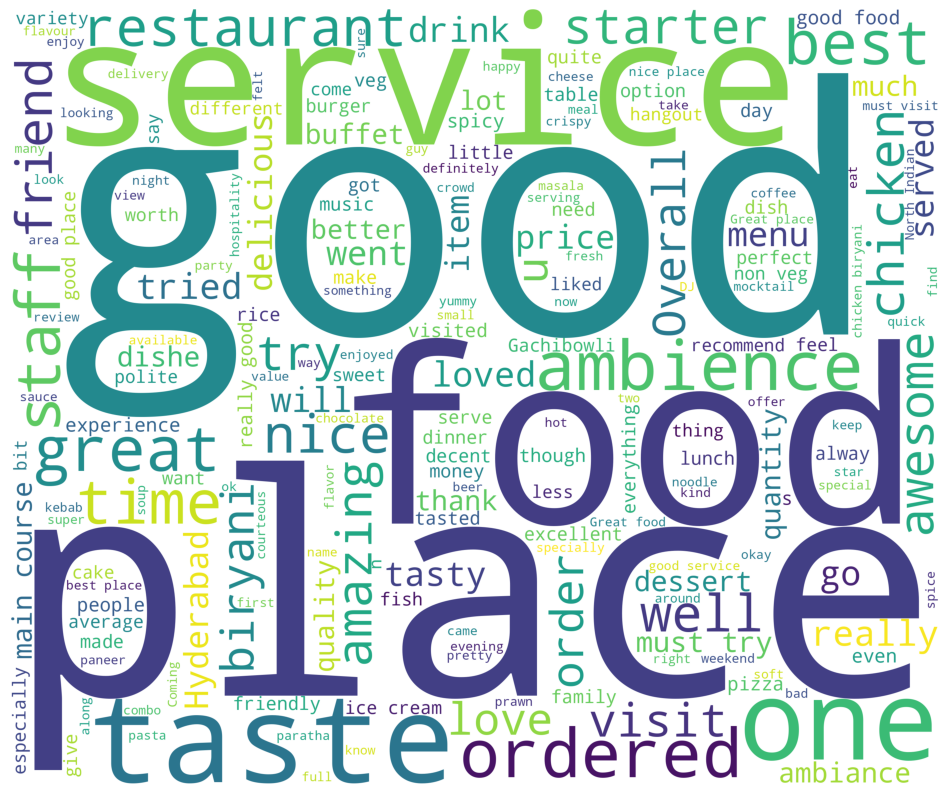

In [18]:
wordcloud = WordCloud(stopwords = STOPWORDS,
                      background_color = 'white',
                      width = 3000,
                      height = 2500
                     ).generate(cleaned_word)


plt.figure(1, figsize = (12, 12))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

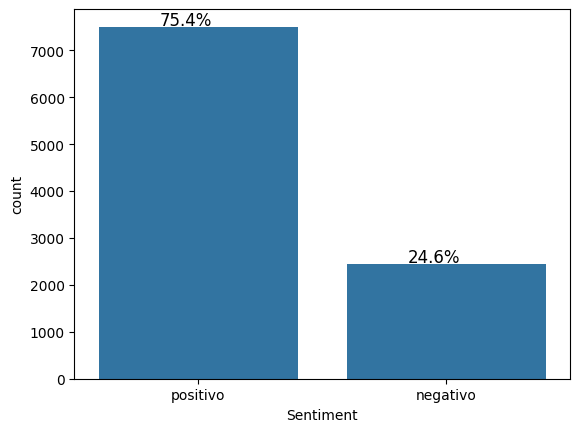

In [19]:
# Graficar la distribución de la etiqueta de clase.
def bar_plot(data, feature):
    # creando el countplot
    plot = sns.countplot(x = feature, data = data)

    # Obteniendo el tamaño de la base
    total = len(data)

    # Creando los %  para cada etiqueta
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y),ha="center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points")
    plt.show()

bar_plot(data,'Sentiment')

Se logra apreciar un claro desbalanceo de clases, el dataset caraece de suficientes comentarios negativos

# **Pre-procesamiento de los datos**

Antes de proceder a construir el modelo, debemos limpiar los datos para obtener un mejor rendimiento del modelo.

In [20]:
data.head()

,Review,Sentiment
0,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was really courteous and helpful.",positivo
1,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,positivo
2,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,positivo
3,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",positivo
4,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,positivo


In [21]:
# Creando el lematizador

lm = WordNetLemmatizer()

In [22]:
data.columns

Index(['Review', 'Sentiment'], dtype='object')

In [23]:
final_corpus = []

for i in range(data.shape[0]):

    # Eliminar los caracteres especiales y los números de los datos.
    review = re.sub('[^a-zA-Z]', ' ', data['Review'][i])

    # Convertir el texto a minúsculas.
    review = review.lower()

    review = review.split()

    # Eliminar las palabras acentuadas.
    review = [unidecode.unidecode(word) for word in review]

    # Eliminar las palabras vacías (stopwords) y crear palabras de léxico (lemmas) para cada palabra presente en cada fila.
    review = [lm.lemmatize(word) for word in review if not word in stopwords.words('english')]

    # Uniendo el corpus.
    review = ' '.join(review)

    # Añadiendo el resultado a una nueva lista llamada "final_corpus".

    final_corpus.append(review)

In [24]:
# Echemos un vistazo al texto limpio.
final_corpus[0]

'ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful'

In [25]:
final_corpus[1]

'ambience good pleasant evening service prompt food good good experience soumen da kudos service'

In [26]:
# Guardando el texto limpio nuevamente en la columna de reseñas.
data['Review'] = final_corpus

In [27]:
data.columns

Index(['Review', 'Sentiment'], dtype='object')

Hemos limpiado con éxito el texto sin procesar y lo hemos guardado nuevamente en el DF. Ahora, construyamos los modelos.

## **Aprendizaje No Supervisado para el Análisis de Sentimientos**

**VADER**

In [28]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sentiment = SentimentIntensityAnalyzer()

In [29]:
data_new = data.copy()   # Realiza una copia de los datos (dataframe)

In [30]:
# Calcula la puntuación de polaridad de las reseñas.
data_new['scores'] = data_new['Review'].apply(lambda text: sentiment.polarity_scores(text))

data_new.head()

,Review,Sentiment,scores
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,positivo,"{'neg': 0.0, 'neu': 0.44, 'pos': 0.56, 'compound': 0.9669}"
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,positivo,"{'neg': 0.0, 'neu': 0.37, 'pos': 0.63, 'compound': 0.936}"
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,positivo,"{'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'compound': 0.9186}"
3,soumen da arun great guy behavior sincerety good food course would like visit place,positivo,"{'neg': 0.0, 'neu': 0.537, 'pos': 0.463, 'compound': 0.8591}"
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,positivo,"{'neg': 0.0, 'neu': 0.393, 'pos': 0.607, 'compound': 0.9432}"


In [31]:
# Extrae la puntuación compuesta (compound score) de las reseñas.
data_new['compound']  = data_new['scores'].apply(lambda score_dict: score_dict['compound'])

data_new.head()

,Review,Sentiment,scores,compound
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,positivo,"{'neg': 0.0, 'neu': 0.44, 'pos': 0.56, 'compound': 0.9669}",0.9669
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,positivo,"{'neg': 0.0, 'neu': 0.37, 'pos': 0.63, 'compound': 0.936}",0.9360
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,positivo,"{'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'compound': 0.9186}",0.9186
3,soumen da arun great guy behavior sincerety good food course would like visit place,positivo,"{'neg': 0.0, 'neu': 0.537, 'pos': 0.463, 'compound': 0.8591}",0.8591
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,positivo,"{'neg': 0.0, 'neu': 0.393, 'pos': 0.607, 'compound': 0.9432}",0.9432


In [32]:
# Clasifica la clase de la reseña estableciendo un umbral en la puntuación compuesta (compound score).

data_new['comp_score'] = data_new['compound'].apply(lambda c: '1' if c >=0 else '0')

data_new.head()

,Review,Sentiment,scores,compound,comp_score
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,positivo,"{'neg': 0.0, 'neu': 0.44, 'pos': 0.56, 'compound': 0.9669}",0.9669,1
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,positivo,"{'neg': 0.0, 'neu': 0.37, 'pos': 0.63, 'compound': 0.936}",0.9360,1
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,positivo,"{'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'compound': 0.9186}",0.9186,1
3,soumen da arun great guy behavior sincerety good food course would like visit place,positivo,"{'neg': 0.0, 'neu': 0.537, 'pos': 0.463, 'compound': 0.8591}",0.8591,1
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,positivo,"{'neg': 0.0, 'neu': 0.393, 'pos': 0.607, 'compound': 0.9432}",0.9432,1


In [33]:
#Asignamos la puntuación de VADER a la base original
data["VADER_pred"] = data_new['comp_score'].tolist()
data.head()

,Review,Sentiment,VADER_pred
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,positivo,1
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,positivo,1
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,positivo,1
3,soumen da arun great guy behavior sincerety good food course would like visit place,positivo,1
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,positivo,1


In [34]:
# Función para imprimir el informe de clasificación y obtener la matriz de confusión en un formato adecuado.

def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['negative', 'positive'], yticklabels = ['negative', 'positive'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

              precision    recall  f1-score   support

           0       0.89      0.49      0.63      2446
           1       0.86      0.98      0.91      7504

    accuracy                           0.86      9950
   macro avg       0.87      0.74      0.77      9950
weighted avg       0.86      0.86      0.84      9950



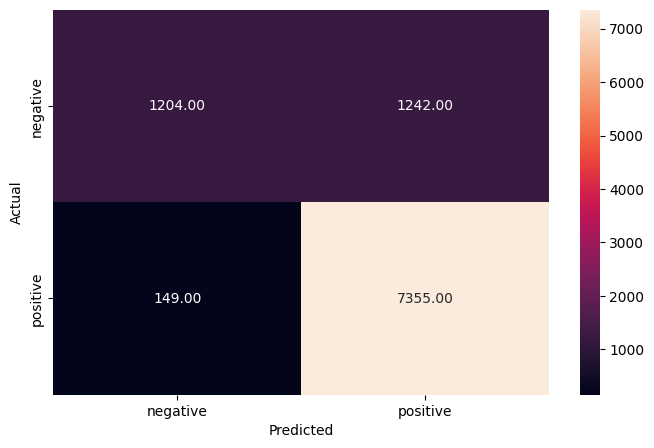

In [35]:
# Calcula la precisión del Análisis de Sentimiento de Vader.
# Mapea 'positivo' a 1 y 'negativo' a 0, luego convierte a int.
# Solo realiza el mapeo si la columna 'Sentiment' todavía contiene etiquetas de cadena
if data["Sentiment"].dtype == 'object':
    data["Sentiment"] = data["Sentiment"].map({"positivo": 1, "negativo": 0}).astype(int)

# Asegura que VADER_pred sea de tipo entero (podría ser string '1', '0' de pasos anteriores)
data["VADER_pred"] = data["VADER_pred"].astype(int)

metrics_score(data["Sentiment"], data["VADER_pred"])

## **TextBlob**

In [36]:
from textblob import TextBlob

In [37]:
data_new = data.copy()

In [38]:
# Calcular la puntuación de polaridad de las reseñas.
data_new['polarity']  = data_new['Review'].apply(lambda text: TextBlob(text).sentiment.polarity)

data_new.head()

,Review,Sentiment,VADER_pred,polarity
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,1,1,0.660000
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,1,1,0.708333
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,1,1,0.550000
3,soumen da arun great guy behavior sincerety good food course would like visit place,1,1,0.750000
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,1,1,0.560000


In [39]:
# Clasificar la clase de la reseña estableciendo un umbral en la puntuación de polaridad.
data_new['polarity_score'] = data_new['polarity'].apply(lambda c: '1' if c >=0 else '0')

data_new.head()

,Review,Sentiment,VADER_pred,polarity,polarity_score
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,1,1,0.660000,1
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,1,1,0.708333,1
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,1,1,0.550000,1
3,soumen da arun great guy behavior sincerety good food course would like visit place,1,1,0.750000,1
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,1,1,0.560000,1


In [40]:
data["Text_Blob_pred"] = data_new['polarity_score'].tolist()
data.head()

,Review,Sentiment,VADER_pred,Text_Blob_pred
0,ambience good food quite good saturday lunch cost effective good place sate brunch one also chill friend parent waiter soumen da really courteous helpful,1,1,1
1,ambience good pleasant evening service prompt food good good experience soumen da kudos service,1,1,1
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also music background amazing,1,1,1
3,soumen da arun great guy behavior sincerety good food course would like visit place,1,1,1
4,food good ordered kodi drumstick basket mutton biryani good thanks pradeep served well enjoyed ambience also good,1,1,1


              precision    recall  f1-score   support

           0       0.79      0.59      0.67      2446
           1       0.88      0.95      0.91      7504

    accuracy                           0.86      9950
   macro avg       0.83      0.77      0.79      9950
weighted avg       0.85      0.86      0.85      9950



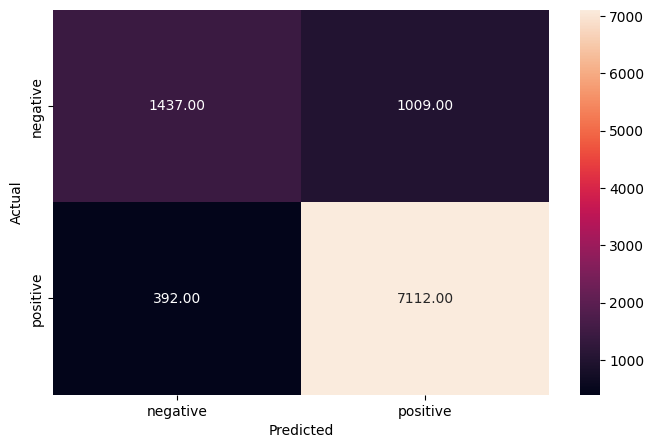

In [41]:
# Calcular la precisión del Análisis de Sentimiento para TEXT BLOB.
data["sentiment"] = data["Sentiment"].astype(int)  #Convertir los valores de la columna de sentimiento en tipo de dato entero (int).

data["Text_Blob_pred"] = data["Text_Blob_pred"].astype(int)  #Convertir los valores de la columna de sentimiento en tipo de dato entero (int).

metrics_score(data["sentiment"], data["Text_Blob_pred"])

**Análisis de Selección**


* Calidad de la información (Precisión): Si bien TextBlob es ligeramente más equilibrado, VADER es mucho más confiable al etiquetar negativos. Con un 89% de precisión en la clase 0, asegura que cuando el modelo detecta una queja, es casi seguro que se trata de un problema real, evitando falsas alarmas para el equipo operativo.

* Detección de Satisfacción (Recall): VADER captura prácticamente todos los comentarios positivos (98% de recall). Esto garantiza que no se pierda ninguna mención favorable, cumpliendo con el objetivo de identificar qué es lo que el cliente más valora del servicio.

* Falsos Positivos: VADER tiene un recall bajo en negativos (49%), lo que significa que dejará pasar algunos comentarios negativos como neutrales o positivos. Sin embargo, prioriza que lo que sí logre clasificar como negativo sea información de alta calidad y veraz.

# **Recomendación Final para el grupo:**




# **Valoración sobre el método actual de identificación**

1. **El Desbalance de Clases**
A pesar de que el método actual de categorización (escalas del 1 al 5) ha sido el pilar para desarrollar este análisis y preparar su implementación en los servidores, se ha identificado un desbalance significativo entre las clases positiva y negativa.

Este fenómeno es una consecuencia directa del sistema de clasificación numérica actual. En muchos casos, las valoraciones en los extremos o en los puntos medios no reflejan con exactitud la carga emocional del texto, lo que genera una distribución desigual que el modelo debe compensar.

2. **Dependencia de la Asignación Inicial**
La efectividad y el éxito a largo plazo del análisis de sentimientos radican en la calidad del etiquetado original. Es imperativo reconocer que:

Si la asignación de la escala (1 al 5) carece de criterios estandarizados o bases sólidas, el modelo enfrentará dificultades de convergencia.

Un etiquetado impreciso introduce "ruido" que impide que los algoritmos alcancen los resultados esperados, limitando la capacidad de predicción.

3. **Recomendación Estratégica**
Para maximizar el retorno de inversión de esta implementación, se sugiere:

Refinar el criterio de captura: Revisar cómo se asocian las escalas numéricas con los comentarios en el punto de venta o encuesta.


# **Finalmente**

Se recomienda la implementación del modelo basado en **VADER**. Su capacidad superior para filtrar ruido en los comentarios negativos (89% de precisión) y su exhaustividad para capturar comentarios positivos (98% de recall) lo alinean mejor con los objetivos estratégicos del grupo restaurantero: mejorar la operación con datos precisos y potenciar los puntos fuertes del servicio.



In [42]:
!jupyter nbconvert --to html "/content/Proyecto_Integrador3_SentimentAnalysis.ipynb"

[NbConvertApp] Converting notebook /content/Proyecto_Integrador3_SentimentAnalysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1790201 bytes to /content/Proyecto_Integrador3_SentimentAnalysis.html
